# Personal Information
Name: **Christoforos Fragkiadakis**

StudentID: **16229460**

Email: [**christoforos.fragkiadakis@student.uva.nl**](christoforos.fragkiadakis@student.uva.nl)

Submitted on: **22.03.2026**

# Data Context
This thesis utilizes the [DIPSER](https://arxiv.org/abs/2502.20209) dataset, a multimodal dataset designed for analyzing student attention and emotion in real-world, in-person classroom settings. Unlike many existing engagement datasets that are collected in online or controlled environments, DIPSER captures naturalistic classroom behavior, incorporating both visual and physiological signals.

The dataset consists of synchronized RGB image sequences, smartwatch sensor data (e.g., heart rate, accelerometer, gyroscope), and annotated labels for attention and emotion. Data is collected across multiple experimental sessions, including activities such traditional learning (passive learning) and brainstorming (interactive learning). Each student is recorded individually using dedicated cameras and wearable sensors, while additional contextual cameras capture the broader classroom environment. Labels are provided both through self-reporting and multiple expert annotators, enabling the study of subjective and external perceptions of engagement.

In [2]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.io as pio
import plotly.express as px
import json

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)
    
pio.renderers.default = "notebook"
sns.set(style="whitegrid")

### Data Loading

Firstly, the data were downloaded from the official [source](https://www.scidb.cn/en/detail?dataSetId=7856c716c0cc4589a23ee4a23d8a0893#p2). It has to be noted that the whole projects consists of total information of 665 GBs. As a subsequent step, the .csv files per group/experiment/subject were generated after following the pipeline from the official [repository](https://github.com/luis-marquez/DIPSEER-A-Dataset-for-In-Person-Student-Emotion-and-Engagement-Recognition-in-the-Wild).

In [3]:
df = pd.read_parquet("Data/dipser_dataset.parquet", engine="pyarrow")
df.head()

,group,time,time_sec,image_path,metadata,subject,experiment,self_labeling emotion,self_labeling attention,labeler_02 attention,labeler_04 attention,labeler_02 emotion,labeler_01 attention,labeler_03 emotion,labeler_03 attention,labeler_01 emotion,labeler_04 emotion,self_labeling emotionfilled,self_labeling attentionfilled,labeler_02 attentionfilled,labeler_04 attentionfilled,labeler_02 emotionfilled,labeler_01 attentionfilled,labeler_03 emotionfilled,labeler_03 attentionfilled,labeler_01 emotionfilled,labeler_04 emotionfilled,samsung_rotation_vector value0_mean,samsung_rotation_vector value0_std,samsung_rotation_vector value1_mean,samsung_rotation_vector value1_std,samsung_rotation_vector value2_mean,samsung_rotation_vector value2_std,samsung_rotation_vector value3_mean,samsung_rotation_vector value3_std,samsung_rotation_vector value4_mean,samsung_rotation_vector value4_std,lsm6dso_gyroscope value0_mean,lsm6dso_gyroscope value0_std,lsm6dso_gyroscope value1_mean,lsm6dso_gyroscope value1_std,lsm6dso_gyroscope value2_mean,lsm6dso_gyroscope value2_std,samsung_linear_acceleration_sensor value0_mean,samsung_linear_acceleration_sensor value0_std,samsung_linear_acceleration_sensor value1_mean,samsung_linear_acceleration_sensor value1_std,samsung_linear_acceleration_sensor value2_mean,samsung_linear_acceleration_sensor value2_std,opt3007_light value0_mean,opt3007_light value0_std,heart_rate,heart_rate_std,accel_magnitude_mean,accel_magnitude_std,gyro_magnitude_mean,gyro_magnitude_std,labeler_05 emotion,labeler_05 attention,labeler_05 emotionfilled,labeler_05 attentionfilled,invalid_reason,gender,age,race,subject_experiment_id,attention,subject_id
0,group01,2026-05-08 10:40:43.047895,0,/home/cfragkiadakis/prjs2039/DIPSER/group01/experiment01/subject_01/images/10_40_43_047895.png,/home/cfragkiadakis/prjs2039/DIPSER/group01/experiment01/subject_01/metadata/10_40_43_047895.json,subject_01,experiment01,6.0,3.0,4.0,3.0,8.0,3.0,9.0,3.0,1.0,7.0,6.0,3.0,4.0,3.0,8.0,3.0,9.0,3.0,1.0,7.0,-0.109524,0.000163,-0.659717,0.000588,0.632875,0.000495,0.390186,0.000218,246.0,0.0,-0.006022,0.006482,-0.003838,0.003665,-0.000864,0.006845,0.052984,0.034713,-0.132399,0.047077,0.017549,0.043508,63.0,0.0,78.0,NaN,0.155556,0.041540,0.011095,0.005498,NaN,NaN,NaN,NaN,valid,male,26.0,white,group01_experiment01_subject_01,3.25,group01_subject_01
1,group01,2026-05-08 10:40:43.195317,0,/home/cfragkiadakis/prjs2039/DIPSER/group01/experiment01/subject_01/images/10_40_43_195317.png,/home/cfragkiadakis/prjs2039/DIPSER/group01/experiment01/subject_01/metadata/10_40_43_195317.json,subject_01,experiment01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.0,3.0,4.0,3.0,8.0,3.0,9.0,3.0,1.0,7.0,-0.109485,0.000109,-0.660015,0.000520,0.632620,0.000426,0.390106,0.000225,246.0,0.0,-0.004508,0.005235,-0.004068,0.003267,-0.001026,0.005944,0.053056,0.036979,-0.124020,0.045047,0.012282,0.043478,63.0,0.0,78.0,NaN,0.148634,0.038779,0.009572,0.004378,NaN,NaN,NaN,NaN,valid,male,26.0,white,group01_experiment01_subject_01,3.25,group01_subject_01
2,group01,2026-05-08 10:40:43.295405,0,/home/cfragkiadakis/prjs2039/DIPSER/group01/experiment01/subject_01/images/10_40_43_295405.png,/home/cfragkiadakis/prjs2039/DIPSER/group01/experiment01/subject_01/metadata/10_40_43_295405.json,subject_01,experiment01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.0,3.0,4.0,3.0,8.0,3.0,9.0,3.0,1.0,7.0,-0.109478,0.000101,-0.660194,0.000514,0.632473,0.000406,0.390043,0.000252,246.0,0.0,-0.004581,0.005193,-0.003897,0.003153,-0.000525,0.005644,0.054420,0.036670,-0.129478,0.044805,0.015730,0.040968,63.0,0.0,78.0,NaN,0.153129,0.038995,0.009384,0.004079,NaN,NaN,NaN,NaN,valid,male,26.0,white,group01_experiment01_subject_01,3.25,group01_subject_01
3,group01,2026-05-08 10:40:43.395835,0,/home/cfragkiadakis/prjs2039/DIPSER/group01/experiment01/subject_01/images/10_40_43_395835.png,/home/cfragkiadakis/prjs2039/DIPSER/group01/experiment01/subject_01/metadata/10_40_43_395835.json,subject_01,experiment01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Na

In [4]:
tst = df.drop_duplicates('subject_id')
tst.shape

(57, 68)

In [6]:
tst['group'].value_counts()

group
group02    21
group01    20
group03    16
Name: count, dtype: int64

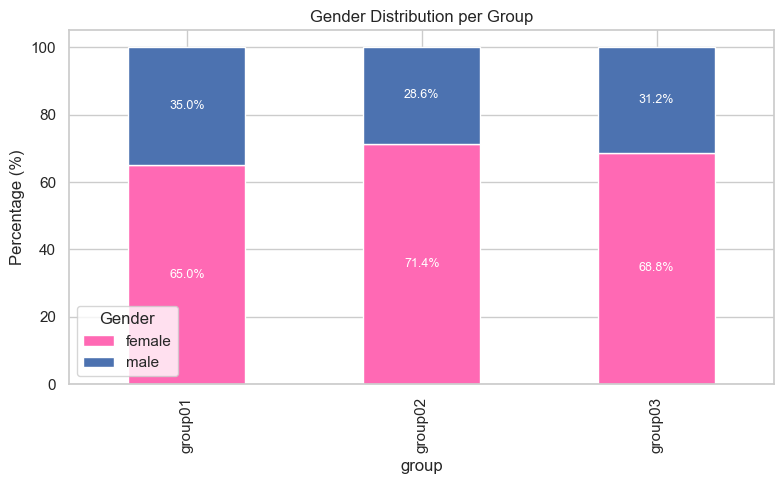

In [5]:
df_unique = df.drop_duplicates(subset=["group", "subject"])

gender_dist = (
    tst.groupby(["group", "gender"])
    .size()
    .unstack(fill_value=0)
)

gender_pct = gender_dist.div(gender_dist.sum(axis=1), axis=0) * 100

colors = {
    "male": "#4C72B0",     # blue
    "female": "#FF69B4"    # pink
}

fig, ax = plt.subplots(figsize=(8,5))

gender_pct.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    color=[colors.get(col, "gray") for col in gender_pct.columns]
)

ax.set_ylabel("Percentage (%)")
ax.set_title("Gender Distribution per Group")
ax.legend(title="Gender")

for i, group in enumerate(gender_pct.index):
    cumulative = 0
    for gender in gender_pct.columns:
        value = gender_pct.loc[group, gender]
        if value > 5:
            ax.text(
                i,
                cumulative + value / 2,
                f"{value:.1f}%",
                ha="center",
                va="center",
                color="white",
                fontsize=9
            )
        cumulative += value

plt.tight_layout()
plt.show()

In [3]:
df.columns

Index(['group', 'time', 'time_sec', 'image_path', 'metadata', 'subject',
       'experiment', 'self_labeling emotion', 'self_labeling attention',
       'labeler_02 attention', 'labeler_04 attention', 'labeler_02 emotion',
       'labeler_01 attention', 'labeler_03 emotion', 'labeler_03 attention',
       'labeler_01 emotion', 'labeler_04 emotion',
       'self_labeling emotionfilled', 'self_labeling attentionfilled',
       'labeler_02 attentionfilled', 'labeler_04 attentionfilled',
       'labeler_02 emotionfilled', 'labeler_01 attentionfilled',
       'labeler_03 emotionfilled', 'labeler_03 attentionfilled',
       'labeler_01 emotionfilled', 'labeler_04 emotionfilled',
       'samsung_rotation_vector value0_mean',
       'samsung_rotation_vector value0_std',
       'samsung_rotation_vector value1_mean',
       'samsung_rotation_vector value1_std',
       'samsung_rotation_vector value2_mean',
       'samsung_rotation_vector value2_std',
       'samsung_rotation_vector value3_mean',

In [4]:
df.isna().sum().head(60)

group                                                  0
time                                                   0
time_sec                                               0
image_path                                             0
metadata                                               0
subject                                                0
experiment                                             0
self_labeling emotion                             885766
self_labeling attention                           886101
labeler_02 attention                              887602
labeler_04 attention                              888157
labeler_02 emotion                                883650
labeler_01 attention                              871709
labeler_03 emotion                                881659
labeler_03 attention                              881030
labeler_01 emotion                                886169
labeler_04 emotion                                888151
self_labeling emotionfilled    

**Raw label columns (labeler_X attention, emotion)**
* Contain values only when a label changes
* All other rows are NaN
* Represent event-based annotations (change points)

**Filled label columns (_attentionfilled, _emotionfilled)**
* Created using forward fill (ffill)
* Propagate the last known value across frames
* Represent a continuous time-series signal
  
For example if attention = 3 at time t, it stays 3 until the next update.


Regarding Labelers 4 and 5, they did not participate in evaluating all experiments of some groups. For some experiments labeler4 participated, and for some others labeler5. There is no experiment on which both labelers 4 and 5 participated.

In [5]:
from itertools import combinations
import numpy as np
import pandas as pd

# Labelers consistently available across all experiments
core_attention_cols = [
    "labeler_01 attentionfilled",
    "labeler_02 attentionfilled",
    "labeler_03 attentionfilled",
    "labeler_04 attentionfilled",
    "labeler_05 attentionfilled"
]

def disagreement_metrics(data, label_cols, prefix="core"):
    labels = data[label_cols].to_numpy(dtype=float)

    valid_pairs = np.zeros(len(data))
    disagreeing_pairs = np.zeros(len(data))
    total_absolute_difference = np.zeros(len(data))

    for i, j in combinations(range(len(label_cols)), 2):
        valid = ~np.isnan(labels[:, i]) & ~np.isnan(labels[:, j])

        valid_pairs[valid] += 1
        disagreeing_pairs[valid] += labels[valid, i] != labels[valid, j]
        total_absolute_difference[valid] += np.abs(
            labels[valid, i] - labels[valid, j]
        )

    return pd.DataFrame(
        {
            f"{prefix}_pair_disagreement": np.divide(
                disagreeing_pairs,
                valid_pairs,
                out=np.full(len(data), np.nan),
                where=valid_pairs > 0,
            ),
            f"{prefix}_mean_abs_pair_diff": np.divide(
                total_absolute_difference,
                valid_pairs,
                out=np.full(len(data), np.nan),
                where=valid_pairs > 0,
            ),
            f"{prefix}_exact_agreement": np.where(
                valid_pairs > 0,
                disagreeing_pairs == 0,
                np.nan,
            ),
            f"{prefix}_label_std": np.nanstd(labels, axis=1),
        },
        index=data.index,
    )

core_metrics = disagreement_metrics(df, core_attention_cols)

ira_df = pd.concat(
    [
        df[
            [
                "subject_id",
                "subject_experiment_id",
                "experiment",
                "group",
                "gender",
                "age",
                "race",
            ]
        ],
        core_metrics,
    ],
    axis=1,
)

ira_df["age_group"] = pd.cut(
    ira_df["age"],
    bins=[13, 20, 22, 26, 44],
)

In [6]:
agreement_outcomes = [
    "core_pair_disagreement",
    "core_mean_abs_pair_diff",
    "core_exact_agreement",
]

# First summarize each student within each experiment
subject_experiment_agreement = (
    ira_df.groupby(
        [
            "subject_id",
            "experiment",
            "gender",
            "age",
            "age_group",
            "race",
        ],
        observed=True,
    )[agreement_outcomes]
    .mean()
    .reset_index()
)

# Remove overall experiment-level differences in annotation difficulty
for outcome in agreement_outcomes:
    subject_experiment_agreement[f"{outcome}_exp_centered"] = (
        subject_experiment_agreement[outcome]
        - subject_experiment_agreement.groupby("experiment")[outcome].transform("mean")
    )

# Each student now contributes one observation
subject_agreement = (
    subject_experiment_agreement.groupby(
        ["subject_id", "gender", "age", "age_group", "race"],
        observed=True,
    )
    .mean(numeric_only=True)
    .reset_index()
)

subject_agreement.groupby("gender")[agreement_outcomes].agg(
    ["count", "mean", "std", "median"]
)

core_pair_disagreement                                \
                        count      mean       std    median   
gender                                                        
female                     39  0.617979  0.099140  0.623811   
male                       18  0.592242  0.111052  0.599325   

       core_mean_abs_pair_diff                                \
                         count      mean       std    median   
gender                                                         
female                      39  0.800387  0.186616  0.806760   
male                        18  0.729520  0.191241  0.691348   

       core_exact_agreement                                
                      count      mean       std    median  
gender                                                     
female                   39  0.098520  0.091976  0.063891  
male                     18  0.111495  0.113200  0.062295

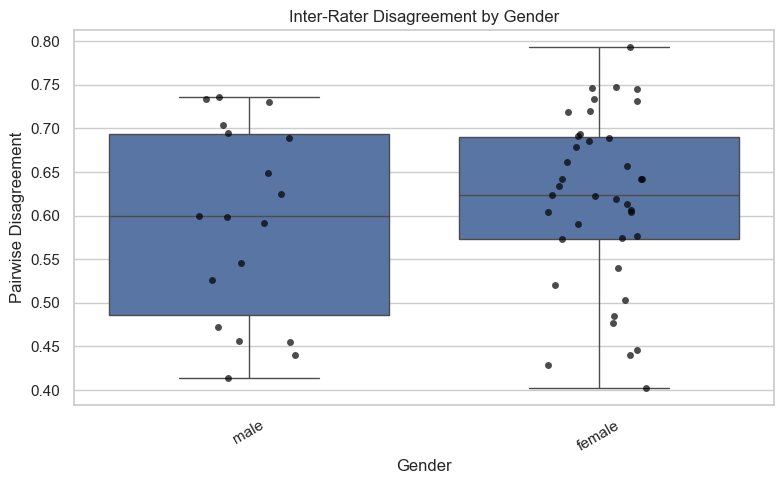

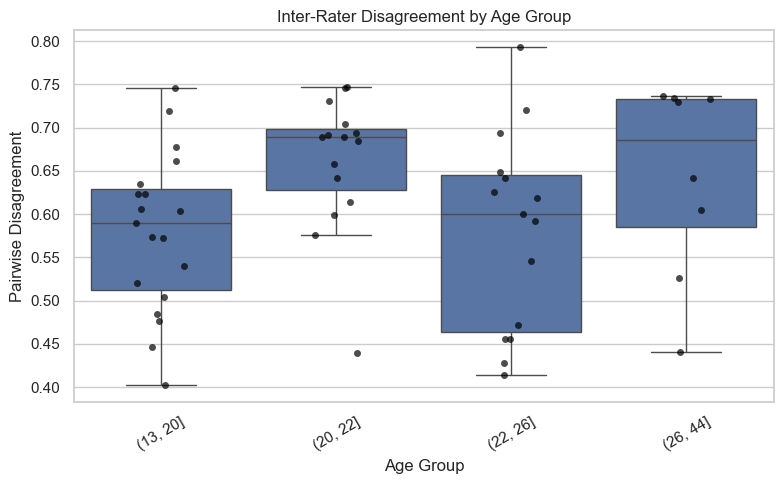

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_disagreement_by_group(data, demographic, outcome):
    plt.figure(figsize=(8, 5))

    sns.boxplot(
        data=data,
        x=demographic,
        y=outcome,
        showfliers=False,
    )

    sns.stripplot(
        data=data,
        x=demographic,
        y=outcome,
        color="black",
        alpha=0.7,
        jitter=0.15,
    )

    plt.title(f"Inter-Rater Disagreement by {demographic.replace('_', ' ').title()}")
    plt.ylabel("Pairwise Disagreement")
    plt.xlabel(demographic.replace("_", " ").title())
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()


plot_disagreement_by_group(
    subject_agreement,
    "gender",
    "core_pair_disagreement",
)

plot_disagreement_by_group(
    subject_agreement,
    "age_group",
    "core_pair_disagreement",
)

In [8]:
def permutation_group_difference(
    data,
    group_col,
    outcome,
    group_a,
    group_b,
    n_permutations=10_000,
    random_state=42,
):
    test_data = data[
        data[group_col].isin([group_a, group_b])
    ][[group_col, outcome]].dropna()

    groups = test_data[group_col].to_numpy()
    values = test_data[outcome].to_numpy()

    observed_difference = (
        values[groups == group_a].mean()
        - values[groups == group_b].mean()
    )

    rng = np.random.default_rng(random_state)
    permuted_differences = np.empty(n_permutations)

    for i in range(n_permutations):
        shuffled_groups = rng.permutation(groups)

        permuted_differences[i] = (
            values[shuffled_groups == group_a].mean()
            - values[shuffled_groups == group_b].mean()
        )

    p_value = (
        np.sum(np.abs(permuted_differences) >= abs(observed_difference)) + 1
    ) / (n_permutations + 1)

    return {
        "group_a": group_a,
        "group_b": group_b,
        "mean_difference": observed_difference,
        "p_value": p_value,
        "n_group_a": int((groups == group_a).sum()),
        "n_group_b": int((groups == group_b).sum()),
    }


# Raw demographic difference
permutation_group_difference(
    subject_agreement,
    group_col="gender",
    outcome="core_pair_disagreement",
    group_a="female",
    group_b="male",
)

{'group_a': 'female',
 'group_b': 'male',
 'mean_difference': np.float64(0.02573677486778414),
 'p_value': np.float64(0.38106189381061895),
 'n_group_a': 39,
 'n_group_b': 18}

C:\Users\cfrag\Desktop\UvA\Thesis\Thesis\venv\lib\site-packages\sklearn\metrics\_classification.py:897: RuntimeWarning: invalid value encountered in scalar divide
  k = np.sum(w_mat * confusion) / np.sum(w_mat * expected)


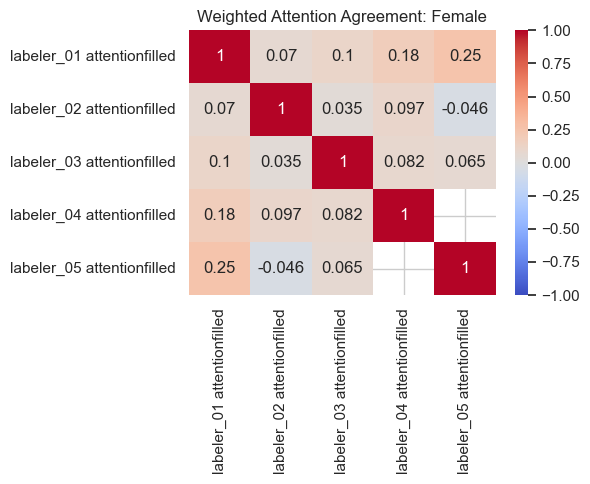

C:\Users\cfrag\Desktop\UvA\Thesis\Thesis\venv\lib\site-packages\sklearn\metrics\_classification.py:897: RuntimeWarning: invalid value encountered in scalar divide
  k = np.sum(w_mat * confusion) / np.sum(w_mat * expected)


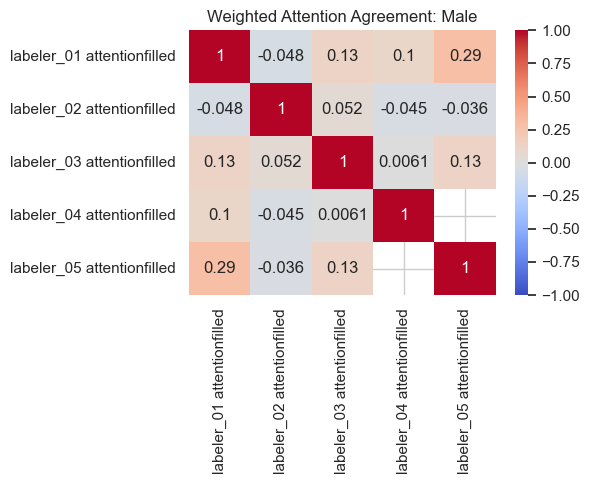

In [9]:
from sklearn.metrics import cohen_kappa_score

def weighted_kappa_matrix(data, label_cols):
    matrix = pd.DataFrame(
        index=label_cols,
        columns=label_cols,
        dtype=float,
    )

    for col_a, col_b in combinations(label_cols, 2):
        valid = data[[col_a, col_b]].dropna()

        kappa = cohen_kappa_score(
            valid[col_a],
            valid[col_b],
            weights="quadratic",
        )

        matrix.loc[col_a, col_b] = kappa
        matrix.loc[col_b, col_a] = kappa

    np.fill_diagonal(matrix.values, 1)
    return matrix


for gender, gender_df in df.groupby("gender"):
    matrix = weighted_kappa_matrix(gender_df, core_attention_cols)

    plt.figure(figsize=(6, 5))
    sns.heatmap(matrix, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
    plt.title(f"Weighted Attention Agreement: {gender.title()}")
    plt.tight_layout()
    plt.show()

In [10]:
# Check the number of subjects and disagreement statistics per age group
age_group_summary = (
    subject_agreement
    .groupby("age_group", observed=True)["core_pair_disagreement"]
    .agg(["count", "mean", "std", "median"])
    .sort_index()
)

age_group_summary

,count,mean,std,median
age_group,,,,
"(13, 20]",19,0.579299,0.091673,0.589989
"(20, 22]",15,0.660363,0.079321,0.689118
"(22, 26]",15,0.580243,0.114979,0.599681
"(26, 44]",8,0.643221,0.112632,0.685626


In [12]:
def permutation_omnibus_test(
    data,
    group_col,
    outcome,
    n_permutations=10_000,
    random_state=42,
):
    test_data = data[[group_col, outcome]].dropna()

    groups = test_data[group_col].astype(str).to_numpy()
    values = test_data[outcome].to_numpy()

    unique_groups = np.unique(groups)
    overall_mean = values.mean()

    def between_group_variation(labels):
        return sum(
            np.sum(labels == group)
            * (values[labels == group].mean() - overall_mean) ** 2
            for group in unique_groups
        )

    observed_statistic = between_group_variation(groups)

    rng = np.random.default_rng(random_state)
    permutation_statistics = np.empty(n_permutations)

    for i in range(n_permutations):
        permutation_statistics[i] = between_group_variation(
            rng.permutation(groups)
        )

    p_value = (
        np.sum(permutation_statistics >= observed_statistic) + 1
    ) / (n_permutations + 1)

    return {
        "n_age_groups": len(unique_groups),
        "n_subjects": len(test_data),
        "between_group_statistic": observed_statistic,
        "p_value": p_value,
    }

In [13]:
age_group_test = permutation_omnibus_test(
    subject_agreement,
    group_col="age_group",
    outcome="core_pair_disagreement",
)

age_group_test

{'n_age_groups': 4,
 'n_subjects': 57,
 'between_group_statistic': np.float64(0.07806451855321728),
 'p_value': np.float64(0.05629437056294371)}

In [14]:
if age_group_test["p_value"] < 0.05:
    print(
        "Inter-rater disagreement differs significantly between "
        "at least some age groups."
    )
else:
    print(
        "No statistically significant difference in inter-rater "
        "disagreement was detected between age groups."
    )

No statistically significant difference in inter-rater disagreement was detected between age groups.


### Attention distribution

We examine the distribution of attention labels. This is critical because class imbalance can bias model training and affect fairness across groups.

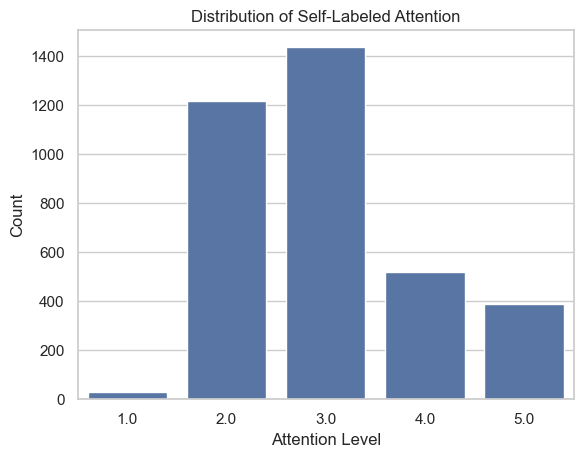

In [4]:
plt.figure()
sns.countplot(x='self_labeling attention', data=df)
plt.title("Distribution of Self-Labeled Attention")
plt.xlabel("Attention Level")
plt.ylabel("Count")
plt.show()

The distribution of self-labeled attention is clearly imbalanced, with the majority of samples concentrated in the mid-range levels (2 and especially 3). Extreme values (1 and 5) are relatively rare.

This suggests that:

Most students are perceived as moderately engaged, rather than clearly disengaged or highly attentive.

The dataset exhibits class imbalance, which may bias models toward predicting the dominant classes (level 2 and 3).

Rare classes (particularly 1 and 5) may be harder to learn, potentially leading to poorer performance and fairness issues for underrepresented engagement states.

This imbalance should be taken into account during modeling, for example through re-weighting or balanced evaluation metrics.

In [5]:
# drop outlier 
df = df[df['self_labeling attentionfilled'] != 7]

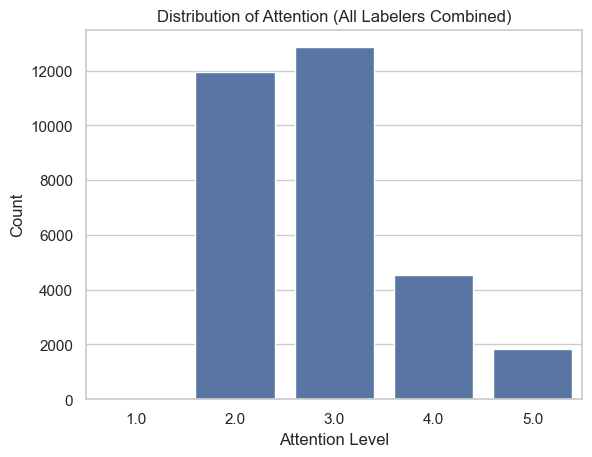

In [6]:
labeler_cols = [
    'labeler_01 attention',
    'labeler_02 attention',
    'labeler_03 attention',
    'labeler_04 attention',
    'labeler_05 attention'
]

df_long = df.melt(
    value_vars=labeler_cols,
    var_name='labeler',
    value_name='attention_score'
)

plt.figure()
sns.countplot(x='attention_score', data=df_long)
plt.title("Distribution of Attention (All Labelers Combined)")
plt.xlabel("Attention Level")
plt.ylabel("Count")
plt.show()

### Emotion Distribution

We analyze the distribution of emotional states. In this thesis we aim to predict the attention label, but knowing the emotion distribution is also useful since it will be used as a feature to our target variable

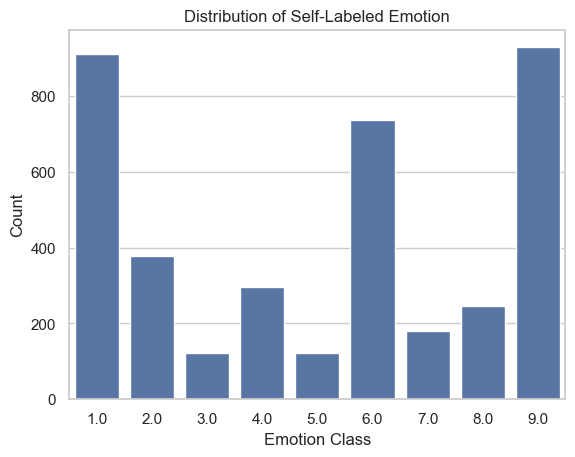

In [7]:
plt.figure()
sns.countplot(x='self_labeling emotion', data=df)
plt.title("Distribution of Self-Labeled Emotion")
plt.xlabel("Emotion Class")
plt.ylabel("Count")
plt.show()

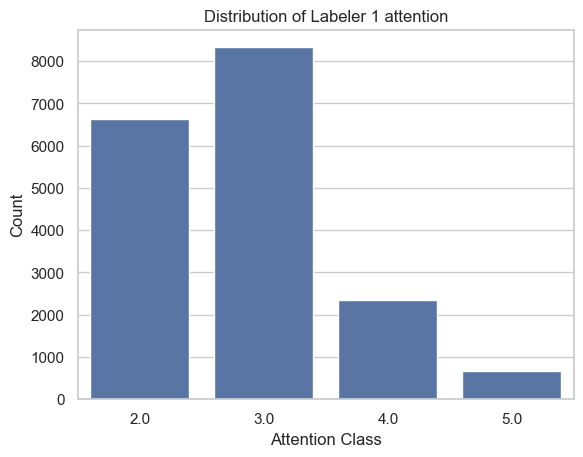

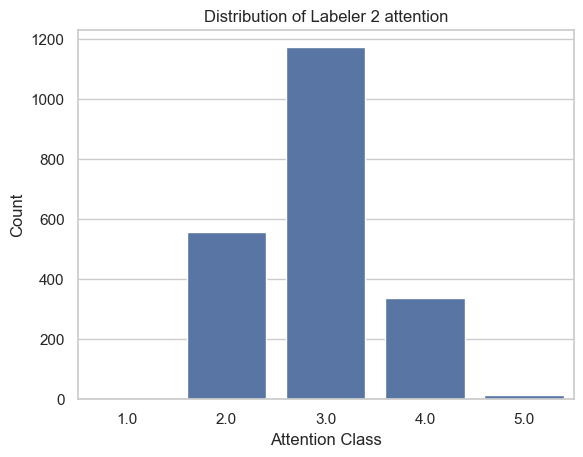

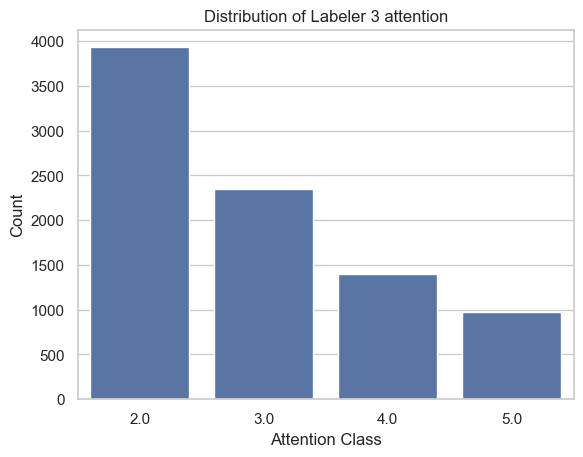

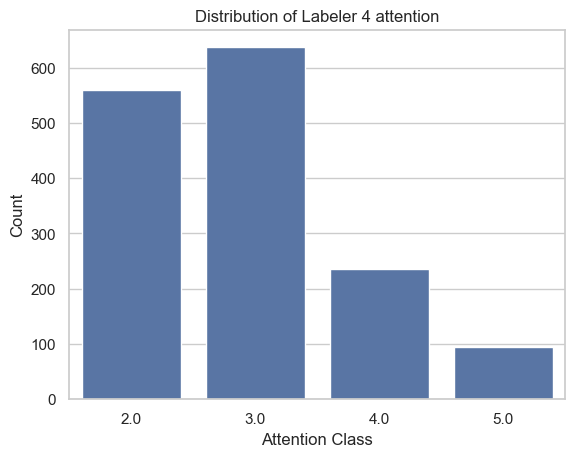

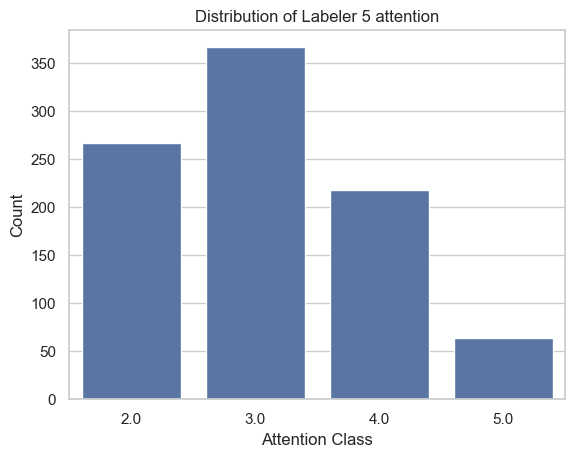

In [24]:
for labeler_n in range(1,6):
    plt.figure()
    sns.countplot(x=f'labeler_0{labeler_n} attention', data=df)
    plt.title(f"Distribution of Labeler {labeler_n} attention")
    plt.xlabel("Attention Class")
    plt.ylabel("Count")
    plt.show()

According to DIPSER paper: "Emotion is categorized into nine categories: 9: Enjoyment, 8: Hope, 7: Pride, 6: Relief, 5: Anger, 4:
Anxiety, 3: Shame, 2: Despair, 1: Boredom."

The distribution of self-labeled emotions is highly imbalanced, with a strong dominance of a few classes. In particular, Boredom (1) and Enjoyment (9) appear most frequently, followed by Relief (6), while several emotions such as Anger (5) and Shame (3) are relatively rare.

This indicates that the dataset is skewed toward low-arousal (e.g., boredom) and positive emotions (e.g., enjoyment, relief), while more intense or negative emotional states are underrepresented.

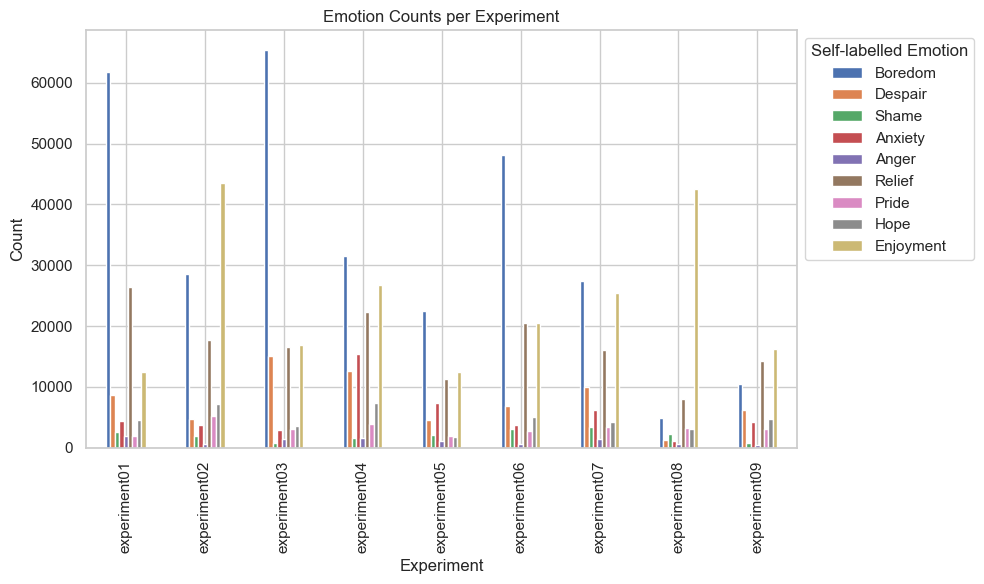

In [8]:
emotion_map = {
    9: "Enjoyment",
    8: "Hope",
    7: "Pride",
    6: "Relief",
    5: "Anger",
    4: "Anxiety",
    3: "Shame",
    2: "Despair",
    1: "Boredom"
}

counts = (
    df.groupby(['experiment', 'self_labeling emotionfilled'])
      .size()
      .unstack(fill_value=0)
)

counts = counts.rename(columns=emotion_map)

counts.plot(kind='bar', stacked=False, figsize=(10,6))
plt.title("Emotion Counts per Experiment")
plt.xlabel("Experiment")
plt.ylabel("Count")
plt.legend(title="Self-labelled Emotion", bbox_to_anchor=(1, 1), loc="upper left")

plt.tight_layout()
plt.show()

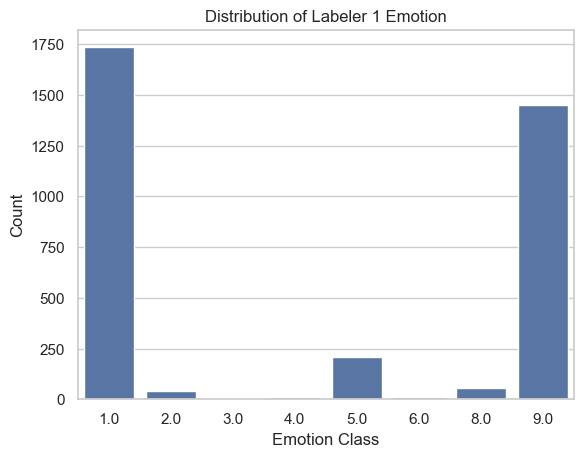

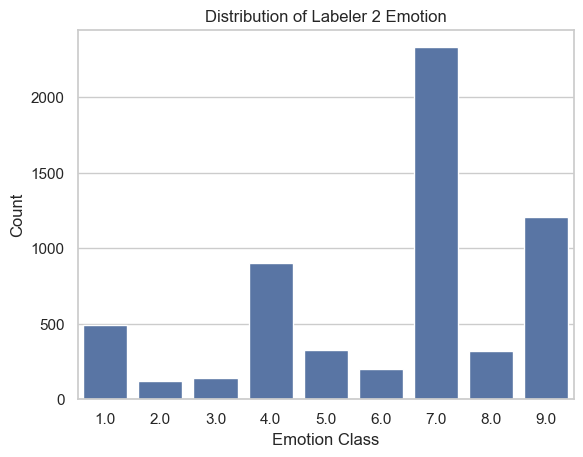

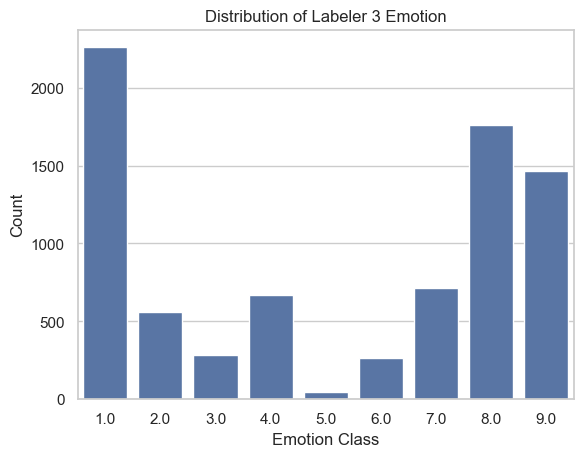

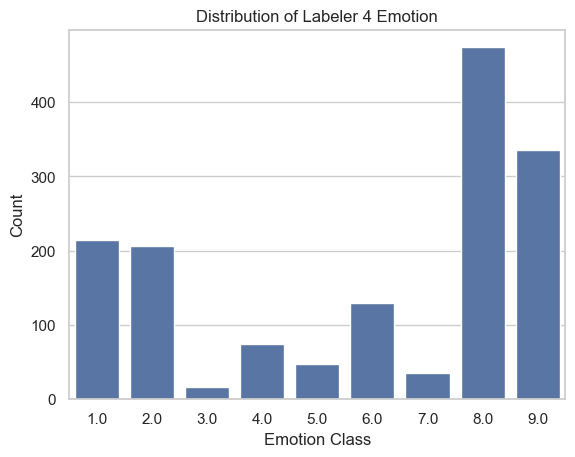

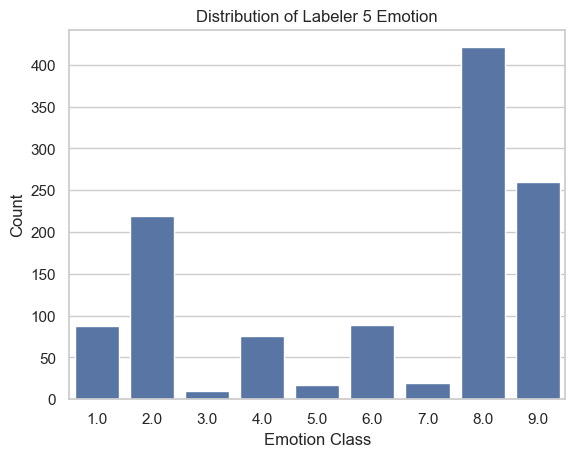

In [9]:
for labeler_n in range(1,6):
    plt.figure()
    sns.countplot(x=f'labeler_0{labeler_n} emotion', data=df)
    plt.title(f"Distribution of Labeler {labeler_n} Emotion")
    plt.xlabel("Emotion Class")
    plt.ylabel("Count")
    plt.show()

In [10]:
# emotion based on consensus
df['emotion'] = df[[
    'labeler_01 emotionfilled',
    'labeler_02 emotionfilled',
    'labeler_03 emotionfilled',
    'labeler_04 emotionfilled',
    'labeler_05 emotionfilled'
]].mode(axis=1)[0]

We derive that the agreement between labelers is very low, so even consensus is not a safe way to derive final emotion label. Averaging is not meaningful because it is not so ordinal like attention label. Emotion will not be used for modelling, not only due to this instability, but also predicting attention with labelers annotations on emotion will violate real-time assumption since there will not be emotion value available. 

There is variation across experiments, indicating that different teaching activities elicit different emotional responses (e.g., experiment02 shows high enjoyment, while experiment03 is dominated by boredom throughout the duration of the experiment).

In [11]:
attention_cols = [
    col for col in df.columns
    if 'attentionfilled' in col and 'self' not in col]

emotion_cols = [
    col for col in df.columns
    if 'emotionfilled' in col and 'self' not in col]

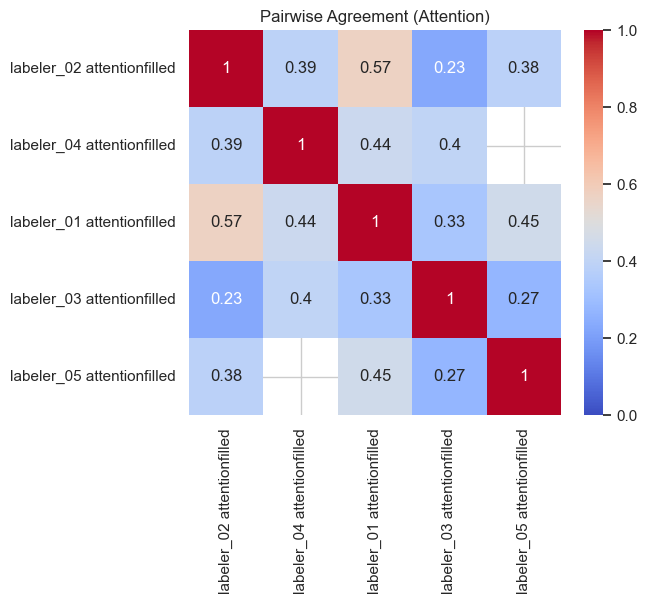

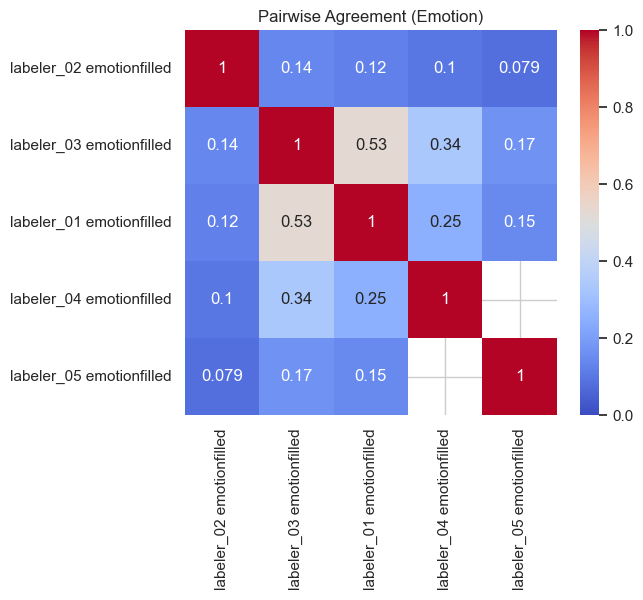

In [12]:
import itertools

def agreement_matrix(df, cols):
    mat = pd.DataFrame(index=cols, columns=cols, dtype=float)

    for a, b in itertools.product(cols, cols):
        valid = df[[a, b]].dropna()

        if len(valid) == 0:
            mat.loc[a, b] = np.nan
        else:
            agreement = (valid[a].values == valid[b].values).mean()
            mat.loc[a, b] = float(agreement)
            
    return mat

# Attention
att_matrix = agreement_matrix(df, attention_cols)

plt.figure(figsize=(6,5))
sns.heatmap(att_matrix, annot=True, cmap="coolwarm", vmin=0, vmax=1)
plt.title("Pairwise Agreement (Attention)")
plt.show()

# Emotion
emot_matrix = agreement_matrix(df, emotion_cols)

plt.figure(figsize=(6,5))
sns.heatmap(emot_matrix, annot=True, cmap="coolwarm", vmin=0, vmax=1)
plt.title("Pairwise Agreement (Emotion)")
plt.show()

* Attention is relatively consistent across annotators
* Emotion labels are highly inconsistent, annotators strongly disagree
* Emotion is much noisier than attention
* Attention is more behaviorally observable and labelers agree more consistenly


-> Choosing Attention label as prediction is a more reliable signal.

In [13]:
# attention
# use averaging to serve as a ground truth label
df['labeler_mean_attention'] = df[attention_cols].mean(axis=1)

# round it to the closest integer for EDA and comparison with self labeling which is also integer in the scale 1-5
df['labeler_mean_attention_cat'] = df['labeler_mean_attention'].round()

In [14]:
# pivot = df.pivot_table(
#     index='labeler_01 emotionfilled',
#     columns='labeler_mean_attention_cat',
#     aggfunc='size',
#     fill_value=0
# )
# sns.heatmap(pivot, annot=True, fmt='d')

### Average Attention per experiment

In [15]:
pd.crosstab(df['self_labeling attentionfilled'], df['labeler_mean_attention_cat'])

labeler_mean_attention_cat,2.0,3.0,4.0,5.0
self_labeling attentionfilled,,,,
1.0,3662,3819,635,0
2.0,81544,185533,18672,0
3.0,89579,264599,47335,45
4.0,14376,111133,28096,27
5.0,3910,17193,17518,0


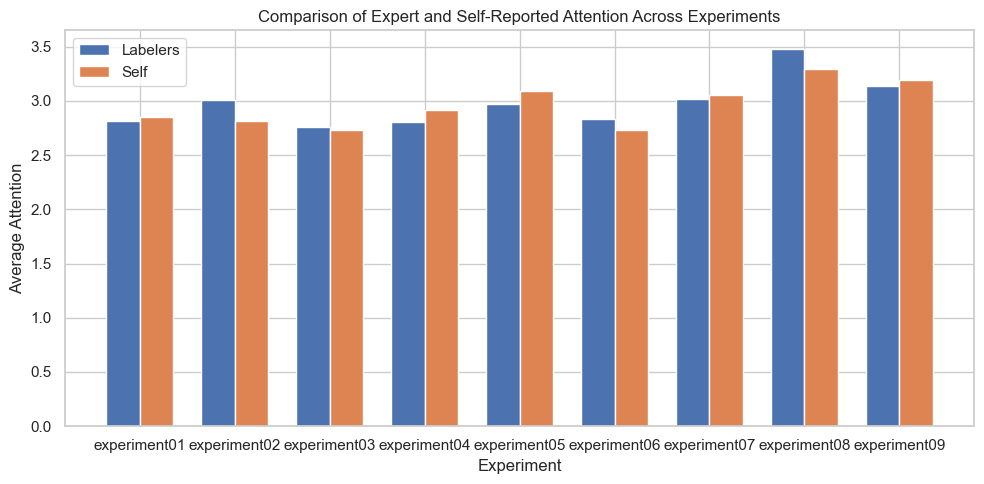

In [16]:
comparison = (
    df
    .groupby('experiment')[['labeler_mean_attention', 'self_labeling attentionfilled']]
    .mean()
    .reset_index()
)

x = comparison['experiment']
x_pos = np.arange(len(x))
width = 0.35

plt.figure(figsize=(10,5))

plt.bar(x_pos - width/2, comparison['labeler_mean_attention'], 
        width=width, label='Labelers')

plt.bar(x_pos + width/2, comparison['self_labeling attentionfilled'], 
        width=width, label='Self')

plt.xlabel("Experiment")
plt.ylabel("Average Attention")
plt.title("Comparison of Expert and Self-Reported Attention Across Experiments")
plt.legend()

plt.xticks(x_pos, x, rotation=0)
plt.tight_layout()
plt.show()

The bar chart compares average attention levels between expert annotators and self-reported measures across experiments. Overall, both signals exhibit similar trends, with attention values consistently ranging between approximately 2.7 and 3.0. In most experiments, expert and self-assessments are closely aligned, indicating general agreement in perceived engagement.

According to labelers, experiment 2 had the highest attention levels.

Recalling the description of each experiment according to DIPSER:

* Session 2: Brainstorming Session - During this creative session, students generate ideas for projects or solutions to problems.
* Session 3: Lecture - A traditional teaching format where the instructor delivers a lecture in front of the class, with minimal to no student interaction.
* Session 6: Individual Presentation of Work - Students randomly selected present their projects to the group.
* Session 7: Knowledge Test - A formal written assessment on a specific subject area, conducted using
Kahoot to evaluate collective knowledge on the material covered in Session 1.

Experiment 2 and 7 seem to have very close attention levels, with experiments 3 and 6 appearing to be 10% lower.

### Mean and Variability across subjects

In [17]:
subject_stats = df.groupby(['group', 'subject'])['self_labeling attention'].agg(['mean', 'std']).reset_index()
subject_stats["text"] = subject_stats['group'] + subject_stats['subject']

fig = px.scatter(
    subject_stats,
    x='mean',
    y='std',
    hover_name='text',
    title="Subject Self-Attention across experiments: Mean and Variability",
    labels={
        'mean': 'Mean Self-Attention',
        'std': 'Std (Variability)'
    }
)

fig.update_traces(textposition='top center')

fig.show()

The scatter plot of mean versus standard deviation of self-reported attention per subject reveals moderate variability in engagement across individuals. Most subjects cluster within a mean attention range of approximately 2.5 to 3.2, indicating generally medium levels of perceived attention. Variability tends to increase slightly with higher mean attention, suggesting that more engaged students may also exhibit greater fluctuations over time. A few outliers are observed, including subjects with very low variability (constant attention, group02 subject 21) and others with higher instability (group01 subject12).

In [18]:
subject_stats_labelers = df.groupby(['group', 'subject'])['labeler_mean_attention'].agg(['mean', 'std']).reset_index()
subject_stats_labelers["text"] = subject_stats_labelers['group'] + subject_stats_labelers['subject']

fig = px.scatter(
    subject_stats_labelers,
    x='mean',
    y='std',
    hover_name='text',
    title="Subject Labeler-Attention across experiments: Mean and Variability",
    labels={
        'mean': 'Mean Labeler Attention',
        'std': 'Std (Variability)'
    }
)

fig.update_traces(textposition='top center')

fig.show()

The scatter plot of mean versus standard deviation of annotator-derived attention per subject shows a relatively tight distribution, indicating consistent labeling across individuals. Most subjects cluster within a mean attention range of approximately 2.7 to 3.1, suggesting moderate to high perceived engagement from external observers. Variability remains generally low, with standard deviation values mostly between 0.3 and 0.45, implying stable annotations over time. Compared to self-reported attention, the annotator-based signal appears more concentrated and less noisy, reflecting a more uniform assessment of engagement across subjects.

### Metadata analysis

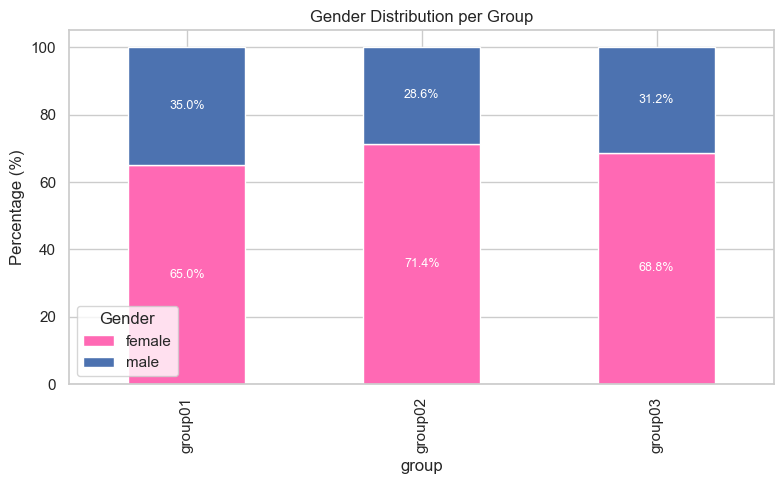

In [19]:
df_unique = df.drop_duplicates(subset=["group", "subject"])

gender_dist = (
    df_unique.groupby(["group", "gender"])
    .size()
    .unstack(fill_value=0)
)

gender_pct = gender_dist.div(gender_dist.sum(axis=1), axis=0) * 100

colors = {
    "male": "#4C72B0",     # blue
    "female": "#FF69B4"    # pink
}

fig, ax = plt.subplots(figsize=(8,5))

gender_pct.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    color=[colors.get(col, "gray") for col in gender_pct.columns]
)

ax.set_ylabel("Percentage (%)")
ax.set_title("Gender Distribution per Group")
ax.legend(title="Gender")

for i, group in enumerate(gender_pct.index):
    cumulative = 0
    for gender in gender_pct.columns:
        value = gender_pct.loc[group, gender]
        if value > 5:
            ax.text(
                i,
                cumulative + value / 2,
                f"{value:.1f}%",
                ha="center",
                va="center",
                color="white",
                fontsize=9
            )
        cumulative += value

plt.tight_layout()
plt.show()

I don't come up with the exact same percentages for each group (+ - 1 male/female per occasion). The only explanation can be due to the fact we have a subset of 4 out of 9 experiments so there are some subjects that participate only in the other 5 experiments.

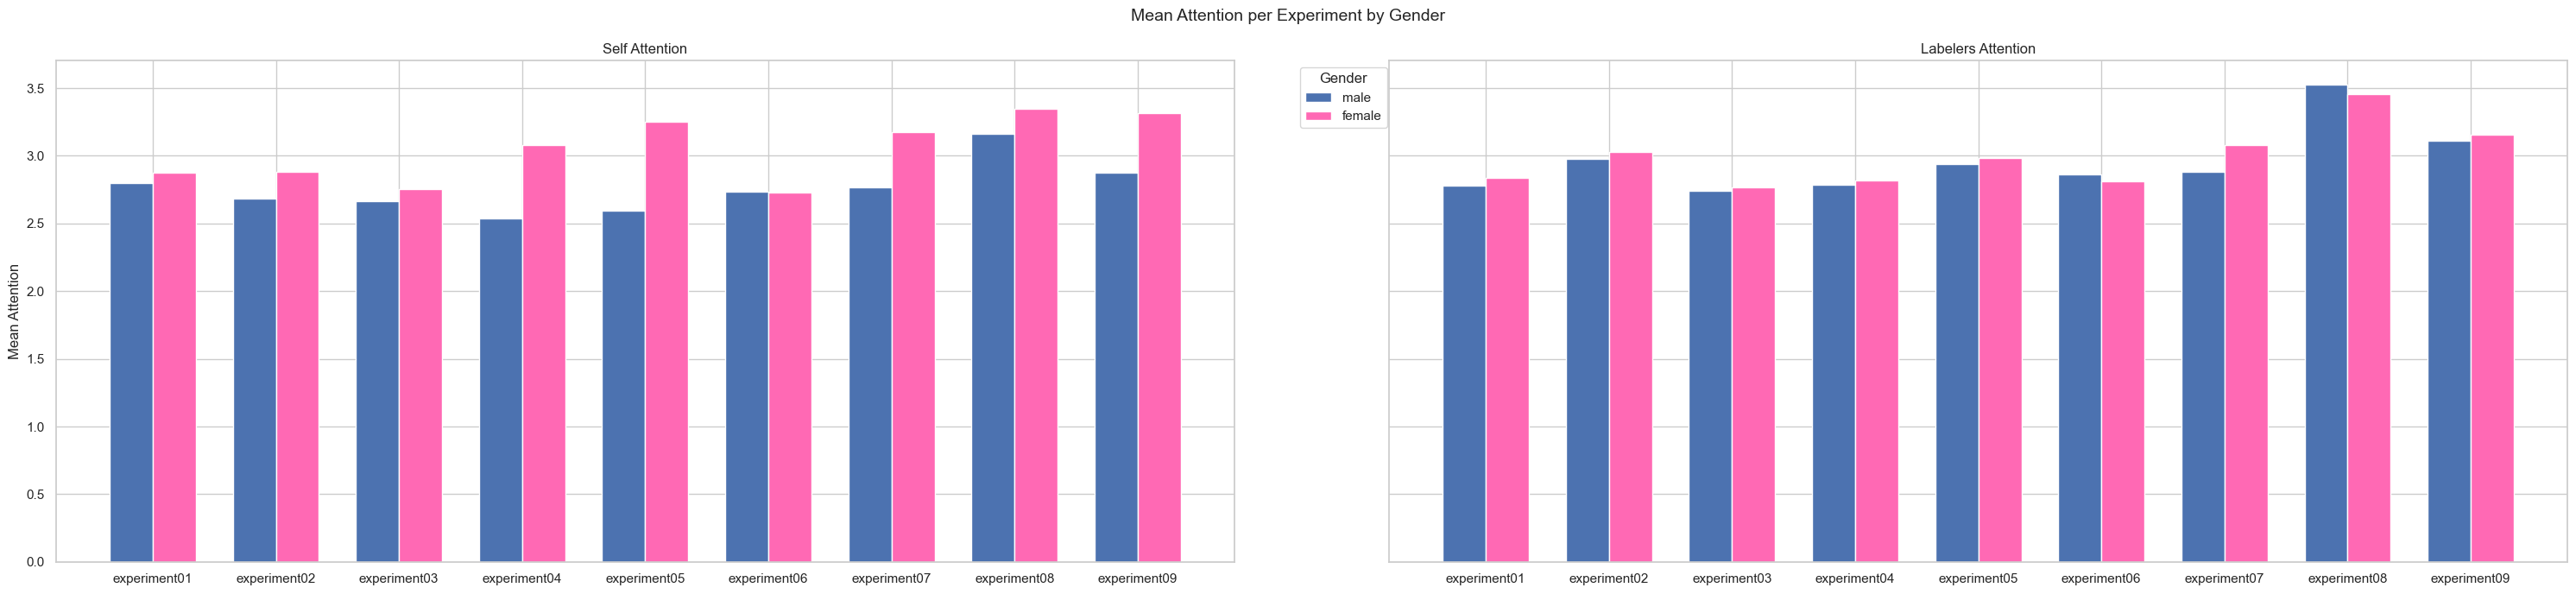

In [20]:
means = df.groupby(["experiment", "gender"])[[
    "labeler_mean_attention",
    "self_labeling attentionfilled"
]].mean().reset_index()

experiments = sorted(means["experiment"].unique())
genders = ["male", "female"]

x = np.arange(len(experiments))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(30,7), sharey=True)

colors = {
    "male": "#4C72B0",   # blue
    "female": "#FF69B4"  # pink
}

# left: Self Attention

ax = axes[0]

for i, gender in enumerate(genders):
    subset = means[means["gender"] == gender]
    subset = subset.set_index("experiment").reindex(experiments)

    ax.bar(
        x + (i - 0.5) * width,
        subset["self_labeling attentionfilled"],
        width,
        label=gender,
        color=colors[gender]
    )

ax.set_title("Self Attention")
ax.set_xticks(x)
ax.set_xticklabels(experiments)
ax.set_ylabel("Mean Attention")
axes[0].legend(title="Gender", bbox_to_anchor=(1.05, 1), loc="upper left")

# right: labelers Attention
ax = axes[1]

for i, gender in enumerate(genders):
    subset = means[means["gender"] == gender]
    subset = subset.set_index("experiment").reindex(experiments)

    ax.bar(
        x + (i - 0.5) * width,
        subset["labeler_mean_attention"],
        width,
        label=gender,
        color=colors[gender]
    )

ax.set_title("Labelers Attention")
ax.set_xticks(x)
ax.set_xticklabels(experiments)

plt.suptitle("Mean Attention per Experiment by Gender", fontsize=14)
plt.tight_layout()
plt.show()

### Average Attention per group and subject according to labellers

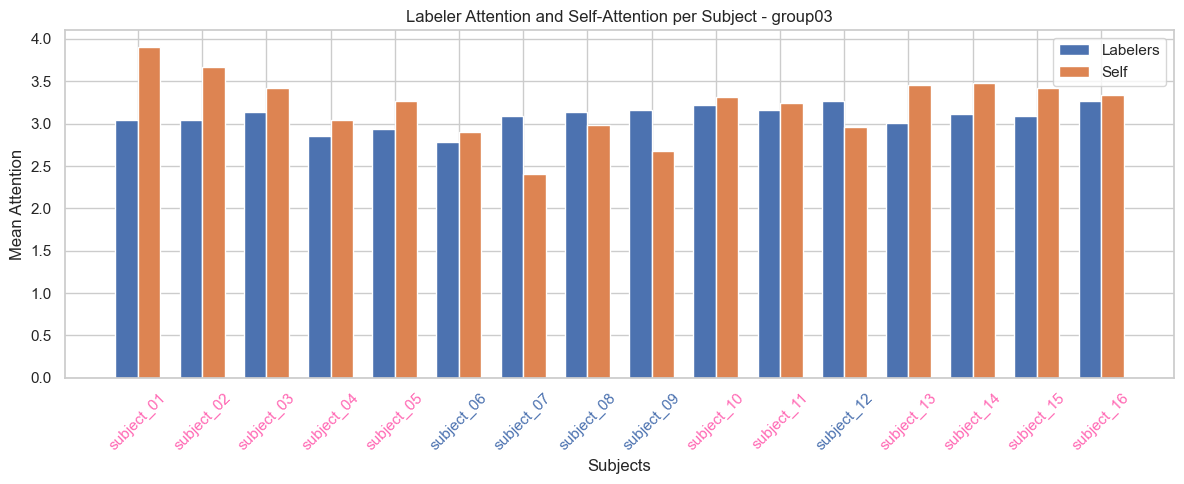

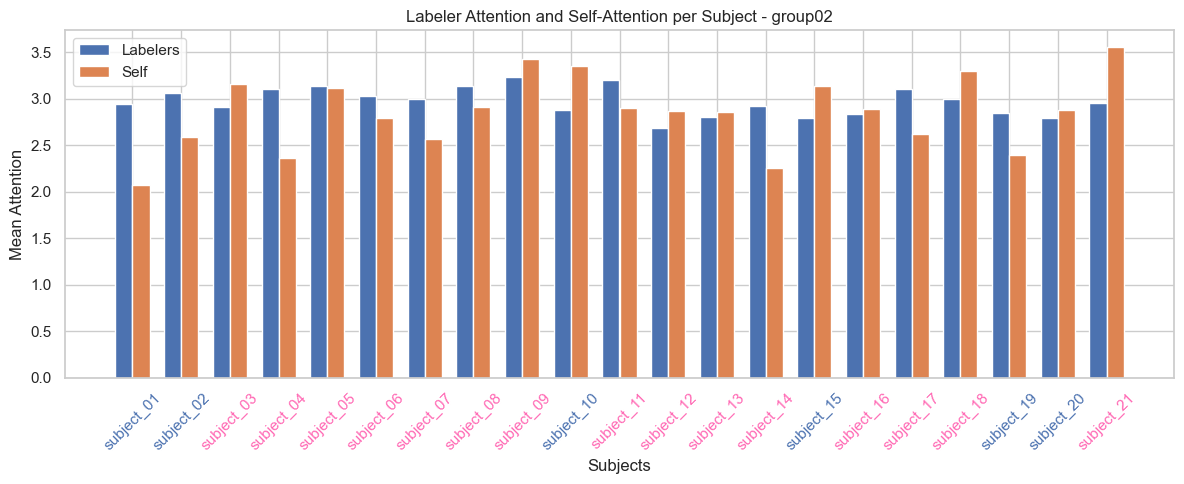

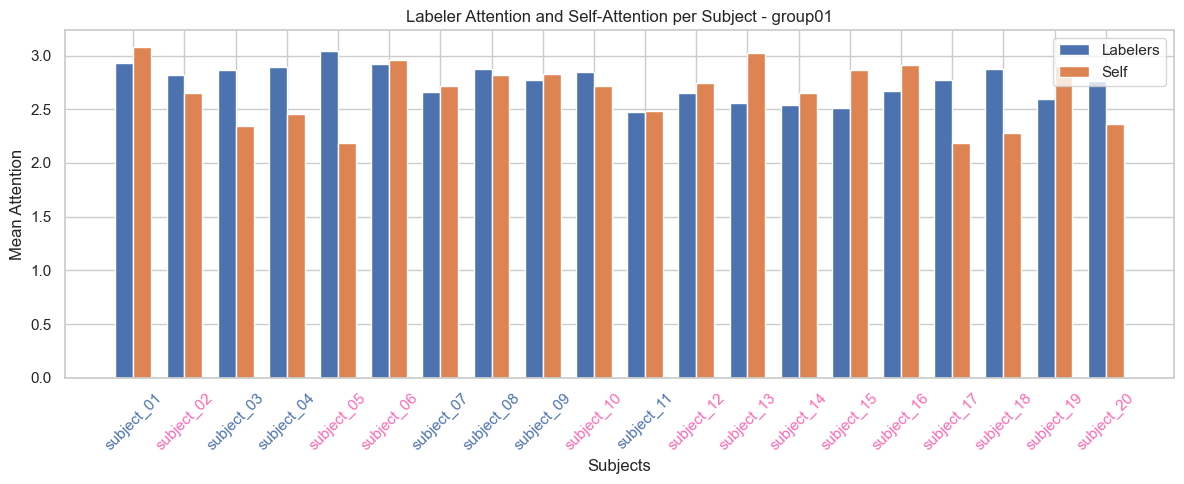

In [21]:
group_subject_attention = (
    df
    .groupby(['group', 'subject'])
    .agg({
        'labeler_mean_attention': 'mean',
        'self_labeling attentionfilled': 'mean',
        'gender': 'first'   # safe because subject has one gender
    })
    .reset_index()
)
groups = set(group_subject_attention['group'])
for g in groups:
    data = group_subject_attention[group_subject_attention['group'] == g]
    
    x = np.arange(len(data))
    width = 0.35

    fig, ax = plt.subplots(figsize=(12,5))
    
    ax.bar(x - width/2, data['labeler_mean_attention'], 
           width=width, label='Labelers')
    
    ax.bar(x + width/2, data['self_labeling attentionfilled'], 
           width=width, label='Self')

    ax.set_title(f"Labeler Attention and Self-Attention per Subject - {g}")
    ax.set_xlabel("Subjects")
    ax.set_ylabel("Mean Attention")
    
    ax.set_xticks(x)
    ax.set_xticklabels(data['subject'], rotation=45)

    for tick_label, gender in zip(ax.get_xticklabels(), data['gender']):
        tick_label.set_color(colors.get(gender, "black"))

    ax.legend()
    
    plt.tight_layout()
    plt.show()

The bar charts comparing mean labeler attention and self-reported attention per subject across the three groups reveal generally consistent but nuanced patterns of agreement and divergence between external and internal assessments of engagement. Across all groups, most subjects exhibit mean attention values within the mid-to-high range (approximately 2.5 to 3.2), indicating overall moderate engagement levels, which aligns with the expected variability of attention across different classroom activities in DIPSER .

In group01, labeler attention tends to be slightly higher and more stable than self-reported attention, with several subjects (e.g., subject_04, subject_05, subject_20) showing noticeably lower self-perception. This suggests a tendency for some students to underestimate their own engagement, or reflects differences in observable vs internal attention cues.

In group02, the alignment between labelers and self-reports is stronger overall, with many subjects showing nearly identical scores. However, a few discrepancies remain (e.g., subject_01 and subject_12), indicating that even in more consistent groups, subjective perception of attention can deviate from expert evaluation.

In group03, self-reported attention is often equal to or higher than labeler scores for several subjects (e.g., subject_01, subject_02, subject_15), suggesting a shift toward overestimation of engagement. This group also exhibits slightly tighter clustering, indicating more homogeneous engagement patterns.

Overall, while there is moderate agreement between labeler and self-attention, systematic biases emerge across groups, ranging from underestimation to overestimation, highlighting the importance of combining both perspectives when modeling engagement. These discrepancies are particularly relevant for fairness-aware modeling, as they may reflect differences in self-perception, expressiveness, or annotation subjectivity across individuals.

In [25]:
df_plot = df.groupby(["group", "gender"])[[
    "labeler_mean_attention",
    "self_labeling attentionfilled"
]].mean().reset_index()

for col in ["labeler_mean_attention", "self_labeling attentionfilled"]:
    df_plot[col + "_pct"] = df_plot[col] / 5 * 100

df_plot["gap_relative_pct"] = (
    (df_plot["self_labeling attentionfilled"] - df_plot["labeler_mean_attention"])
    / df_plot["labeler_mean_attention"]
) * 100

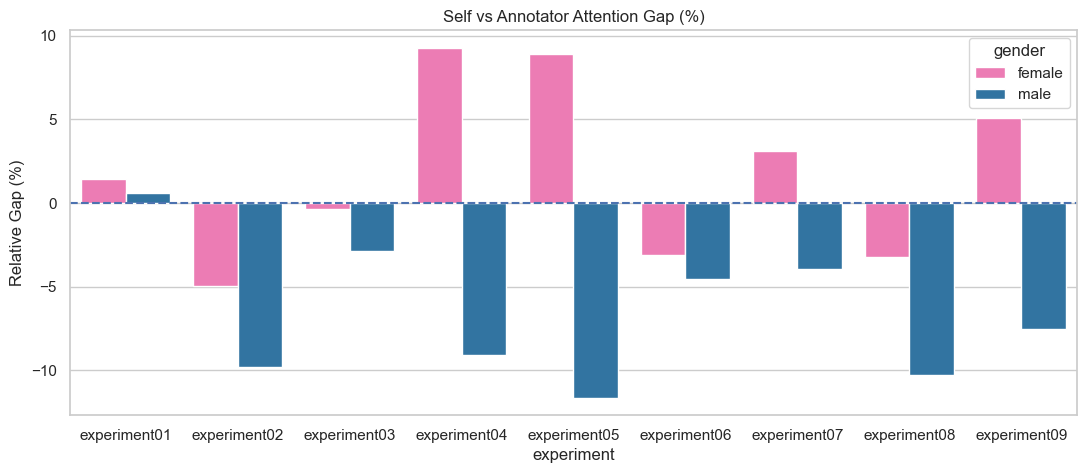

In [23]:
plt.figure(figsize=(13,5))

sns.barplot(
    data=df_plot,
    x="experiment",
    y="gap_relative_pct",
    hue="gender",
    palette={"female": "#FF69B4", "male": "#1f77b4"}  # pink & blue
)

plt.title("Self vs Annotator Attention Gap (%)")
plt.axhline(0, linestyle="--")
plt.ylabel("Relative Gap (%)")
# plt.savefig("figs/attention_gap.png", dpi=300, bbox_inches="tight")
plt.show()

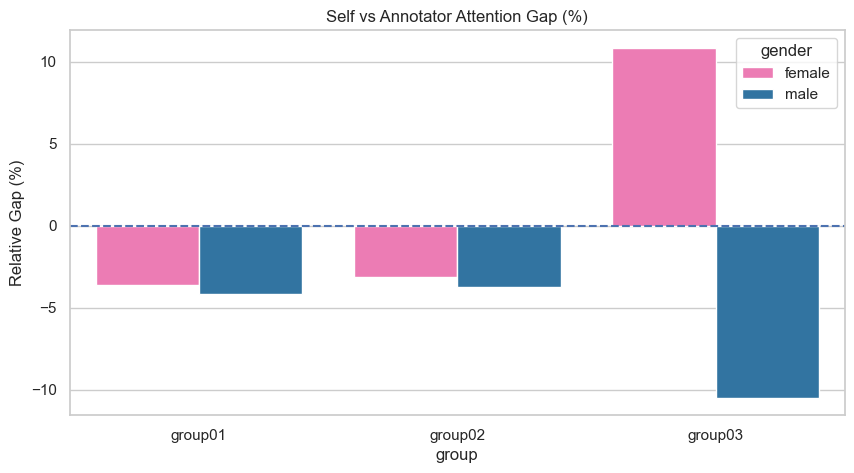

In [26]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=df_plot,
    x="group",
    y="gap_relative_pct",
    hue="gender",
    palette={"female": "#FF69B4", "male": "#1f77b4"}  # pink & blue
)

plt.title("Self vs Annotator Attention Gap (%)")
plt.axhline(0, linestyle="--")
plt.ylabel("Relative Gap (%)")
# plt.savefig("figs/attention_gap.png", dpi=300, bbox_inches="tight")
plt.show()

The discrepancy between self-reported and externally annotated attention is consistently larger (more negative) for male students, indicating a systematic tendency to underestimate their own engagement compared to annotator assessments.

Across experiments 2, 3 and 5, female participants consistently report slightly higher self-attention than males, with the difference being most pronounced in experiment05. This pattern is also reflected in the labelers’ assessments, where females are again rated marginally higher than males, though the gap is generally smaller compared to self-reports. Overall, both self and external evaluations follow similar trends across experimental conditions, suggesting that engagement differences are relatively stable, with only minor gender-based variation.

## Heart Rate

In [3]:
import pandas as pd

In [3]:
df = pd.read_parquet("Data/dipser_dataset.parquet", engine="pyarrow")

In [5]:
# df['time'] = pd.to_timedelta(df['time'].dt.strftime('%H:%M:%S.%f'))
# # sort
# df = df.sort_values(['group', 'experiment', 'subject', 'time'])
# df['subject_experiment_id'] = df['group'] + "_" + df['experiment'] + "_" + df['subject'] 
# # recompute start time
# #df['start_time'] = df.groupby(['group', 'subject', 'experiment'])['time'].transform('min')
# df['start_time'] = df.groupby(['subject', 'experiment'])['time'].transform('min')
# # df['start_time'] = df.groupby(['subject_experiment_id'])['time'].transform('min')

# # recompute relative seconds
# df['relative_time_sec'] = (df['time'] - df['start_time']).dt.total_seconds()

# # inspect
# print(df['relative_time_sec'].describe())
# print(df['relative_time_sec'].max())

In [9]:
import numpy as np

In [28]:
df['time_sec'].isna().sum()

np.int64(0)

In [29]:
tst = df[df['heart_rate'] !=0]

In [32]:
df_subj = (
    tst.groupby(['subject_experiment_id', 'time_sec'])
    ['heart_rate']
    .mean()
    .reset_index()
) # first this groupby otherwise a subject with more rows in some frames contributes more for no reason

df_subj['exp'] = df_subj['subject_experiment_id'].str.split('_').str[-3]

In [33]:
#df_subj[df_subj['experiment'] == 'experiment05']

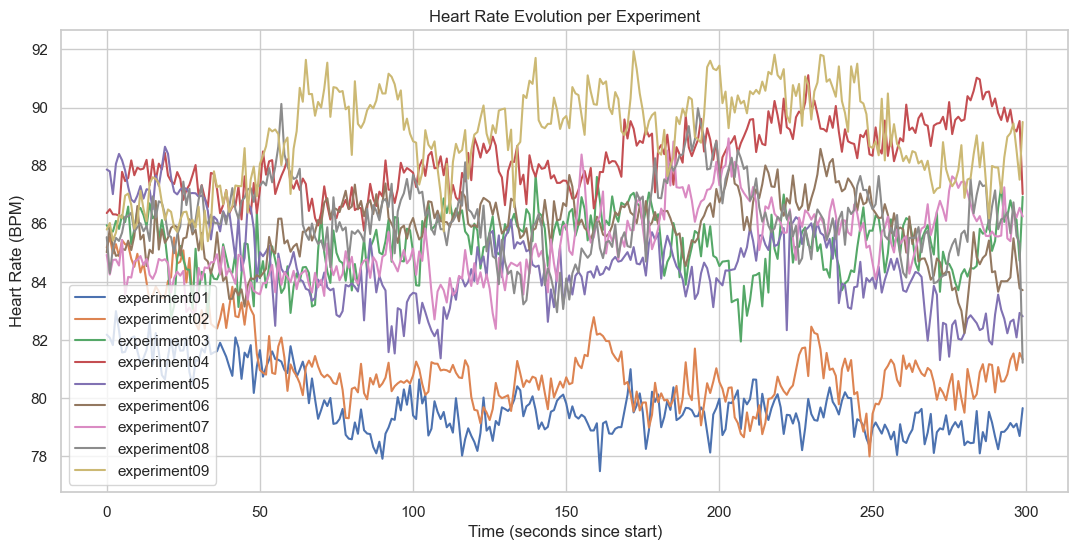

In [34]:
df_exp = (
    df_subj.groupby(['exp', 'time_sec'])
    ['heart_rate']
    .mean()
    .reset_index())

plt.figure(figsize=(13,6))


for exp in df_exp['exp'].unique():
    subset = df_exp[df_exp['exp'] == exp]
    plt.plot(subset['time_sec'], subset['heart_rate'],
             label=exp)

plt.xlabel("Time (seconds since start)")
plt.ylabel("Heart Rate (BPM)")

plt.title("Heart Rate Evolution per Experiment")
plt.legend()
plt.show()

### Attention levels through time

In [39]:
df_subj = (
    df.groupby(['subject', 'experiment', 'gender_name', 'time_bin'])
    ['labeler_mean_attention']
    .mean()
    .reset_index()
) # first this groupby otherwise a subject with more rows in some frames contributes more for no reason

In [40]:
df_att = (
    df_subj.groupby(['experiment', 'time_bin'])['labeler_mean_attention']
    .mean()
    .reset_index())

df_att_gen = (
    df_subj.groupby(['experiment', 'gender_name', 'time_bin'])['labeler_mean_attention']
    .mean()
    .reset_index())

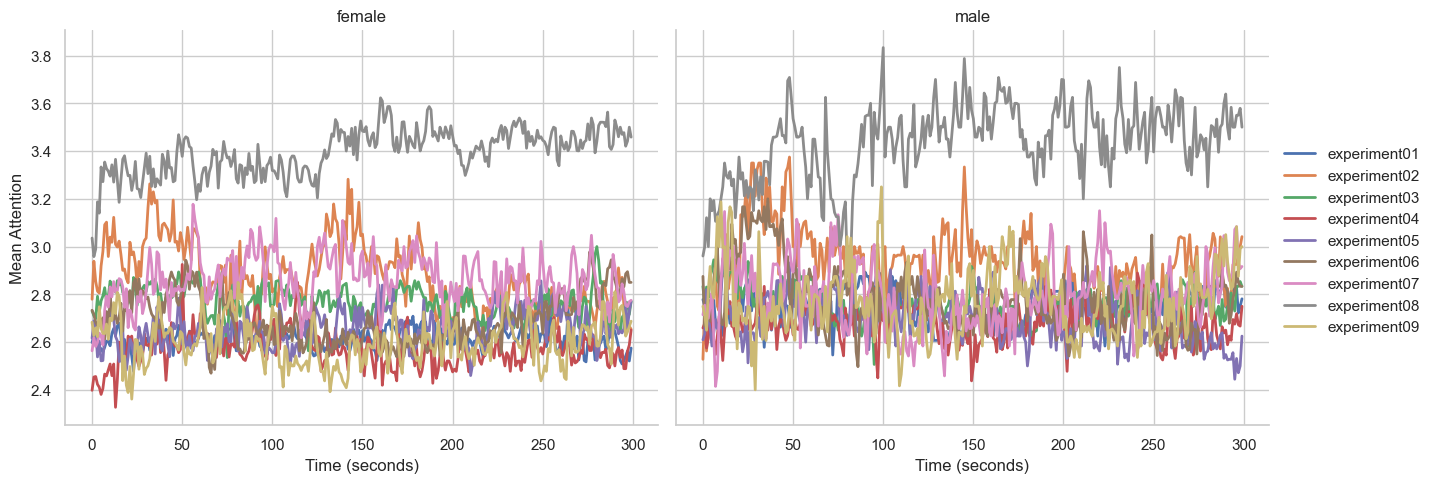

In [41]:
g = sns.FacetGrid(df_att_gen, col="gender_name", height=5, aspect=1.3)

g.map_dataframe(
    sns.lineplot,
    x='time_bin',
    y='labeler_mean_attention',
    hue='experiment',
    linewidth=2
)

g.add_legend()
g.set_axis_labels("Time (seconds)", "Mean Attention")
g.set_titles("{col_name}")

## Age Group

In [4]:
df["age_group"] = pd.cut(df["age"], bins=[13, 20, 22, 26, 44])
df['age_group'].value_counts(normalize=True)

age_group
(13, 20]    0.310612
(20, 22]    0.289337
(22, 26]    0.259549
(26, 44]    0.140501
Name: proportion, dtype: float64

In [5]:
df_unique = df.drop_duplicates(subset=["group", "subject"])
age = (
    df_unique.groupby(['age_group', 'group'])
    .size()
    .unstack(fill_value=0)
)
age

C:\Users\cfrag\AppData\Local\Temp\ipykernel_36736\97841855.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_unique.groupby(['age_group', 'group'])


group,group01,group02,group03
age_group,,,
"(13, 20]",8,11,0
"(20, 22]",3,6,6
"(22, 26]",7,4,4
"(26, 44]",2,0,6


In [6]:
df_unique = df.drop_duplicates(subset=["group", "subject"])
age = (
    df_unique.groupby(
        ['age_group', 'gender', 'group'],
        dropna=False
    )
    .size()
    .unstack(fill_value=0))
age

C:\Users\cfrag\AppData\Local\Temp\ipykernel_36736\1886340801.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_unique.groupby(


group             group01  group02  group03
age_group gender                           
(13, 20]  female        8       11        0
          male          0        0        0
(20, 22]  female        3        3        6
          male          0        3        0
(22, 26]  female        2        1        2
          male          5        3        2
(26, 44]  female        0        0        3
          male          2        0        3

C:\Users\cfrag\AppData\Local\Temp\ipykernel_36736\4202439903.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_unique.groupby(["group", "age_group"])


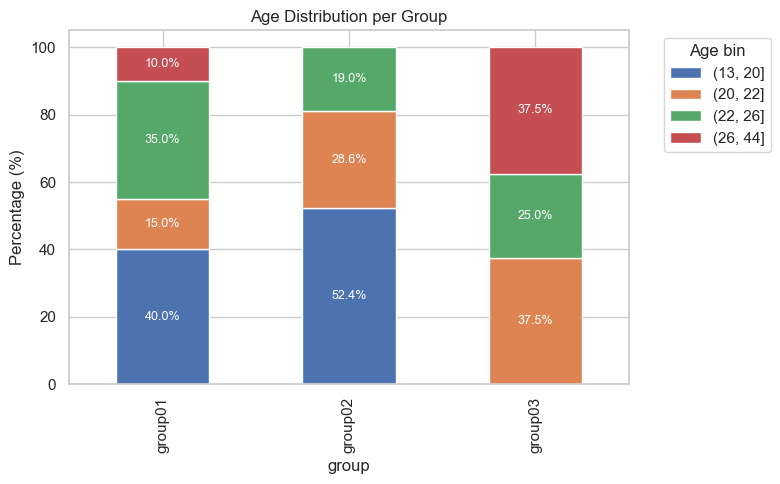

In [7]:
age_dist = (
    df_unique.groupby(["group", "age_group"])
    .size()
    .unstack(fill_value=0)
)

age_pct = age_dist.div(age_dist.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(8,5))

age_pct.plot(
    kind="bar",
    stacked=True,
    ax=ax,
)

ax.set_ylabel("Percentage (%)")
ax.set_title("Age Distribution per Group")
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left", title="Age bin")

for i, group in enumerate(age_pct.index):
    cumulative = 0
    for gender in age_pct.columns:
        value = age_pct.loc[group, gender]
        if value > 5:
            ax.text(
                i,
                cumulative + value / 2,
                f"{value:.1f}%",
                ha="center",
                va="center",
                color="white",
                fontsize=9
            )
        cumulative += value

plt.tight_layout()
plt.show()

C:\Users\cfrag\AppData\Local\Temp\ipykernel_17828\2231717626.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_means = df.groupby("age_group")[[


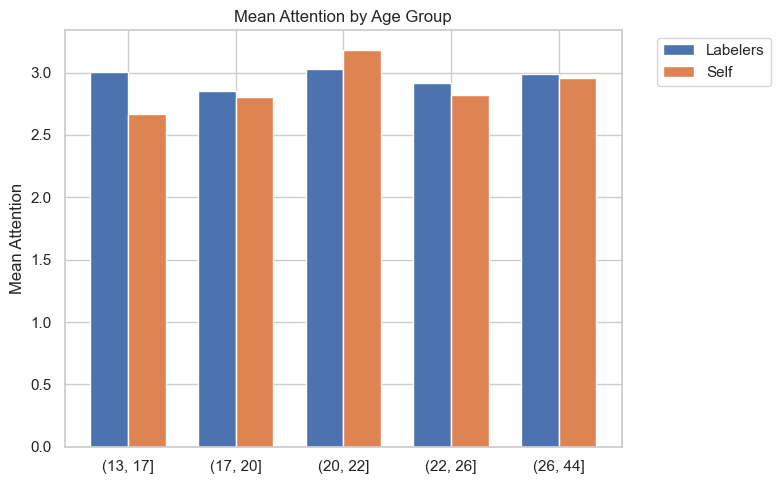

In [52]:
age_means = df.groupby("age_group")[[
    "labeler_mean_attention",
    "self_labeling attentionfilled"
]].mean()

# Ensure correct order
age_means = age_means.sort_index()

x = np.arange(len(age_means.index))
width = 0.35

plt.figure(figsize=(8,5))

plt.bar(
    x - width/2,
    age_means["labeler_mean_attention"],
    width,
    label="Labelers",
)

plt.bar(
    x + width/2,
    age_means["self_labeling attentionfilled"],
    width,
    label="Self",
)

plt.xticks(x, age_means.index)
plt.ylabel("Mean Attention")
plt.title("Mean Attention by Age Group")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()

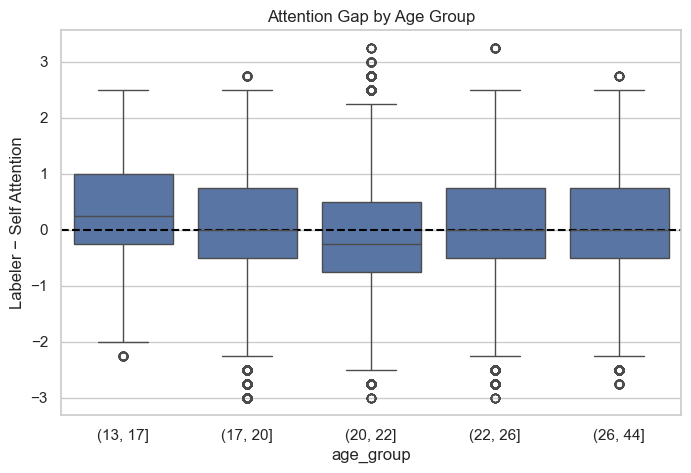

In [53]:
df['attention_gap'] = df['labeler_mean_attention'] - df["self_labeling attentionfilled"]

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="age_group",
    y="attention_gap"
)

plt.axhline(0, linestyle="--", color="black")
plt.title("Attention Gap by Age Group")
plt.ylabel("Labeler − Self Attention")

plt.show()

C:\Users\cfrag\AppData\Local\Temp\ipykernel_8844\633551398.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_plot = df.groupby(["experiment", "age_group"])[[


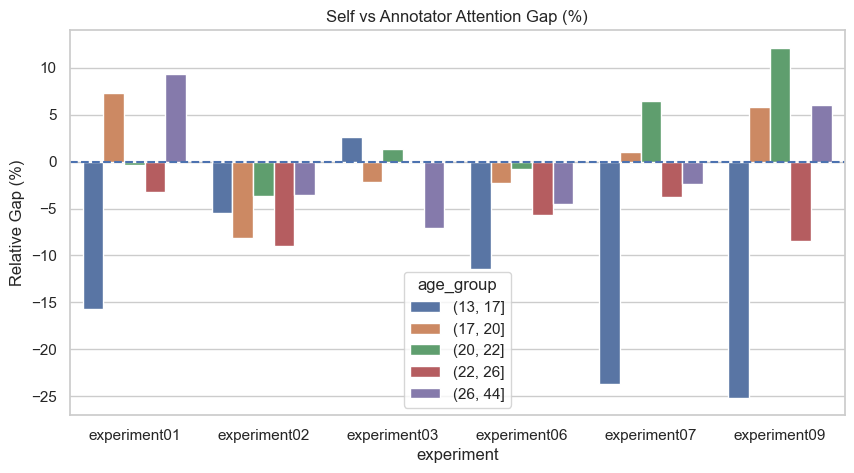

In [44]:
df_plot = df.groupby(["experiment", "age_group"])[[
    "labeler_mean_attention",
    "self_labeling attentionfilled"
]].mean().reset_index()

for col in ["labeler_mean_attention", "self_labeling attentionfilled"]:
    df_plot[col + "_pct"] = df_plot[col] / 5 * 100

df_plot["gap_relative_pct"] = (
    (df_plot["self_labeling attentionfilled"] - df_plot["labeler_mean_attention"])
    / df_plot["labeler_mean_attention"]
) * 100

plt.figure(figsize=(10,5))

sns.barplot(
    data=df_plot,
    x="experiment",
    y="gap_relative_pct",
    hue="age_group",
    #palette={"female": "#FF69B4", "male": "#1f77b4"}  # pink & blue
)

plt.title("Self vs Annotator Attention Gap (%)")
plt.axhline(0, linestyle="--")
plt.ylabel("Relative Gap (%)")
# plt.savefig("figs/attention_gap.png", dpi=300, bbox_inches="tight")
plt.show()

C:\Users\cfrag\AppData\Local\Temp\ipykernel_17828\4238527802.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_plot = df.groupby(["group", "age_group"])[[


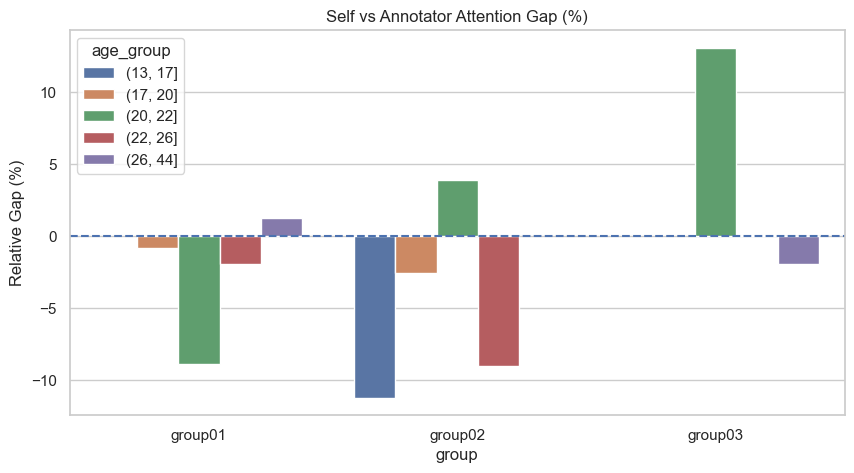

In [54]:
df_plot = df.groupby(["group", "age_group"])[[
    "labeler_mean_attention",
    "self_labeling attentionfilled"
]].mean().reset_index()

for col in ["labeler_mean_attention", "self_labeling attentionfilled"]:
    df_plot[col + "_pct"] = df_plot[col] / 5 * 100

df_plot["gap_relative_pct"] = (
    (df_plot["self_labeling attentionfilled"] - df_plot["labeler_mean_attention"])
    / df_plot["labeler_mean_attention"]
) * 100

plt.figure(figsize=(10,5))

sns.barplot(
    data=df_plot,
    x="group",
    y="gap_relative_pct",
    hue="age_group",
    #palette={"female": "#FF69B4", "male": "#1f77b4"}  # pink & blue
)

plt.title("Self vs Annotator Attention Gap (%)")
plt.axhline(0, linestyle="--")
plt.ylabel("Relative Gap (%)")
# plt.savefig("figs/attention_gap.png", dpi=300, bbox_inches="tight")
plt.show()

# RACE

In [55]:
df.groupby(['gender','race'])['attention_gap'].mean().reset_index()

,gender_name,race,attention_gap
0,female,asian,0.585909
1,female,latino_hispanic,0.065761
2,female,white,-0.064203
3,male,white,0.156254


In [56]:
gender_race = (
    df_unique.groupby(["race", "gender"])
    .size()
    .unstack(fill_value=0)
)
gender_race

gender_name,female,male
race,,
asian,1,0
latino_hispanic,2,0
white,36,18


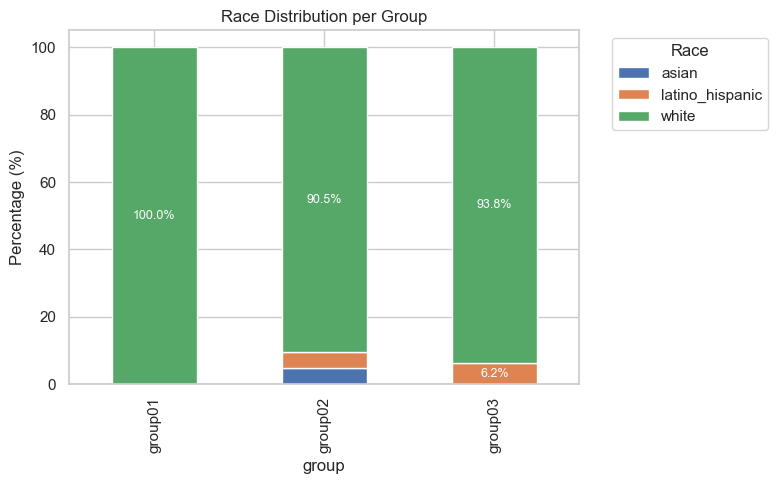

In [60]:
race_dist = (
    df_unique.groupby(["group", "race"])
    .size()
    .unstack(fill_value=0)
)

race_pct = race_dist.div(race_dist.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(8,5))

race_pct.plot(
    kind="bar",
    stacked=True,
    ax=ax,
)

ax.set_ylabel("Percentage (%)")
ax.set_title("Race Distribution per Group")
ax.legend(title="Race", bbox_to_anchor=(1.05, 1), loc="upper left")

for i, group in enumerate(race_pct.index):
    cumulative = 0
    for gender in race_pct.columns:
        value = race_pct.loc[group, gender]
        if value > 5:
            ax.text(
                i,
                cumulative + value / 2,
                f"{value:.1f}%",
                ha="center",
                va="center",
                color="white",
                fontsize=9
            )
        cumulative += value

plt.tight_layout()
plt.show()

In [61]:
df_unique['race'].value_counts()

race
white              54
latino_hispanic     2
asian               1
Name: count, dtype: int64

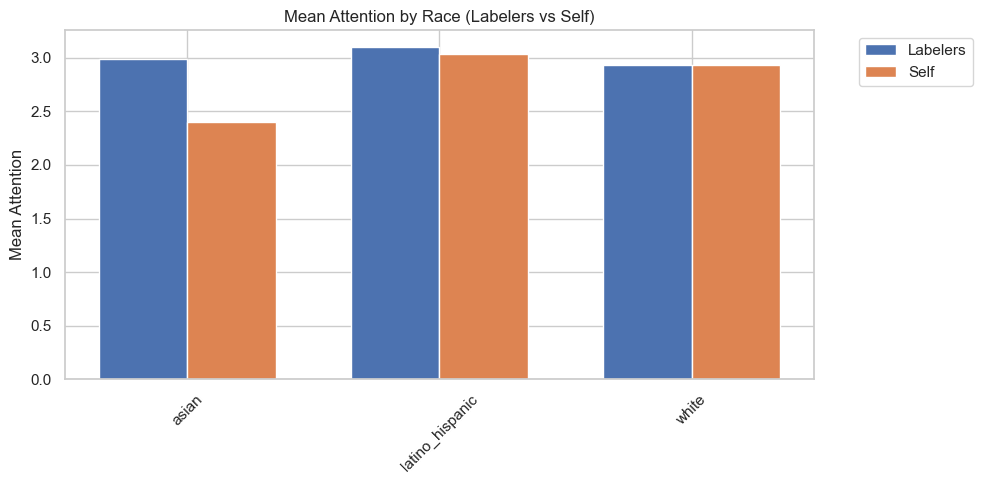

In [62]:
race_means = df.groupby("race")[[
    "labeler_mean_attention",
    "self_labeling attentionfilled"
]].mean()

x = np.arange(len(race_means.index))
width = 0.35

plt.figure(figsize=(10,5))

plt.bar(x - width/2, race_means["labeler_mean_attention"], width, label="Labelers")
plt.bar(x + width/2, race_means["self_labeling attentionfilled"], width, label="Self")

plt.xticks(x, race_means.index, rotation=45)
plt.ylabel("Mean Attention")
plt.title("Mean Attention by Race (Labelers vs Self)")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()

The dataset is heavily dominated by White participants (29 female, 16 male), while other groups are sparsely represented (e.g., Asian: 2 female, 0 male; Middle Eastern: 2 female, 1 male). As a result, variability in smaller groups is likely driven by a few subjects, making the estimates less reliable.

There is a small but consistent gender difference within the White group, where annotators slightly underestimate female engagement relative to self-reports, while male engagement is rated closer to (or slightly above) self-perception.

For the White group, which is the most well-represented, labeler and self attention are closely aligned, indicating no substantial bias. The results of middle eastern and asian should not be interpreted as there are only 3 and 2 subjects on each group as shown in the table above.

Attention levels are relatively consistent across age groups, with both annotator and self-reported scores showing similar trends. Overall, differences across age groups are modest, indicating no strong age-based bias, though small systematic shifts in perception are observable.